In [1]:
import pandas as pd;
import numpy as np;
import matplotlib.pyplot as plt;
import seaborn as sns;

In [2]:
df=pd.read_csv("Downloads/train_u6lujuX_CVtuZ9i (1).csv")

In [3]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
df.shape

(614, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [6]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [7]:
df.isna().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [8]:
df.duplicated().sum() # no duplicates in the data

0

In [9]:
df.skew() 

ApplicantIncome      6.539513
CoapplicantIncome    7.491531
LoanAmount           2.677552
Loan_Amount_Term    -2.362414
Credit_History      -1.882361
dtype: float64

# data is sckewed so use median to fill numerical null values. If data is normally distributed use mean

In [10]:
#treat numeric null values first
num_cols = df.select_dtypes(include='number').columns
for col in num_cols:
    median_value = df[col].median()
    df[col].fillna(median_value, inplace=True)

In [11]:
#i am going to fill na values of categorical columns with mode values
cat_cols=df.select_dtypes(exclude='number').columns
for col in cat_cols:
    mode_value = df[col].mode()[0] #i am using [0] incase of 2 values having same mode , it will take 1st value
    df[col].fillna(mode_value,inplace=True)

In [12]:
df.isna().sum() # succesfully removed null values

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

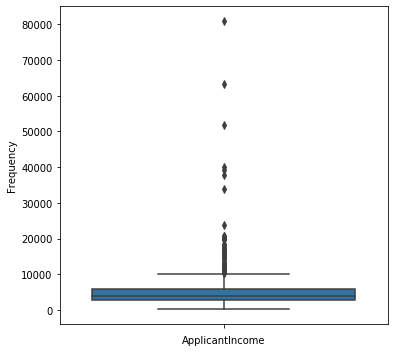

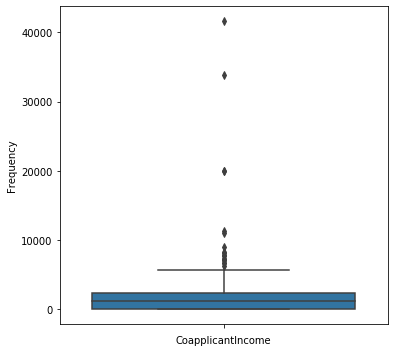

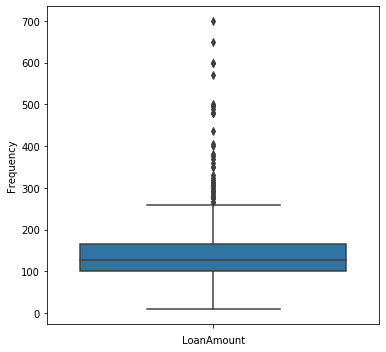

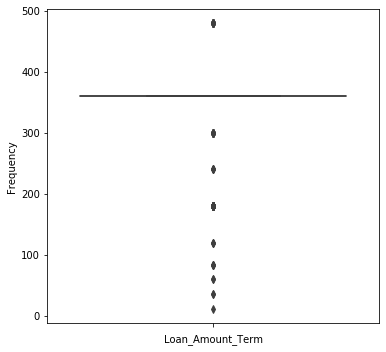

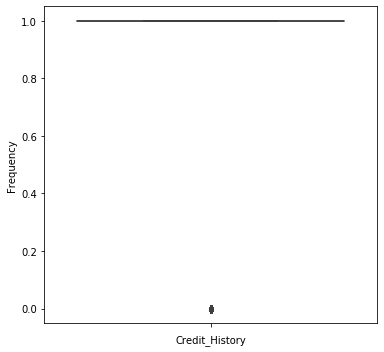

In [13]:
# finding outliers using box plot
def boxplt(col):
    plt.figure(figsize=(15,5))
    plt.subplot(1, 3, 1)
    sns.boxplot(y=df[col])
    plt.xlabel(f'{col}')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()
    return
for col in df.select_dtypes(include='number').columns:
    boxplt(col)

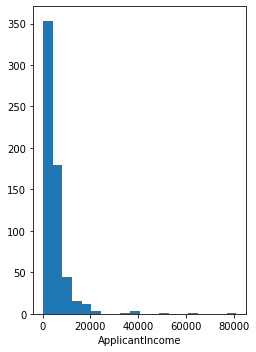

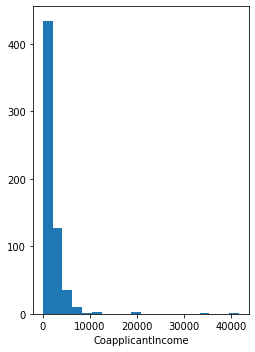

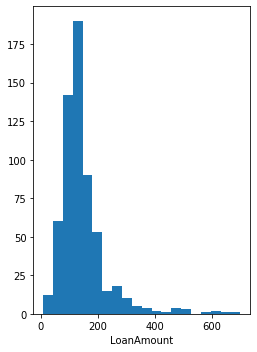

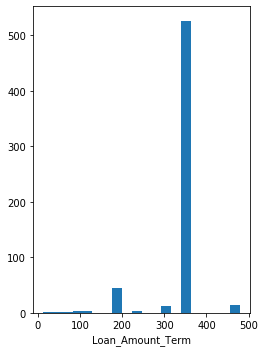

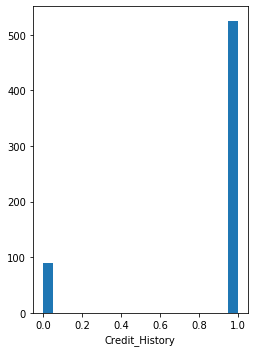

In [14]:
#plotting histograms
def histplt(col):
    plt.figure(figsize=(10,5))
    plt.subplot(1,3,1)
    plt.hist(df[col],bins=20)
    plt.xlabel(f"{col}")
    plt.tight_layout()
    plt.show()
    return
for col in df.select_dtypes(include='number').columns:
    histplt(col)

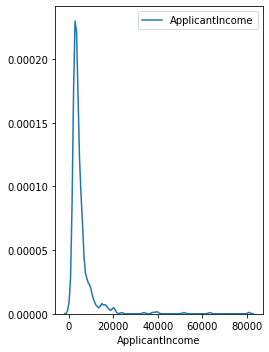

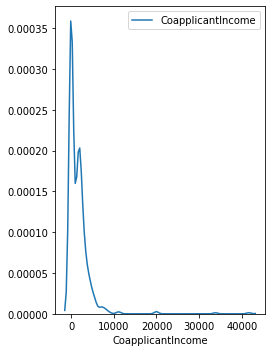

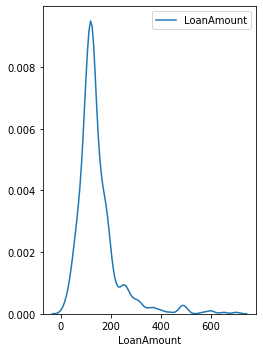

RuntimeError: Selected KDE bandwidth is 0. Cannot estiamte density.

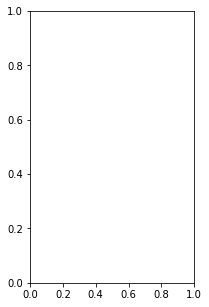

In [15]:
#plotting kde to find distribution
def kdeplt(col):
    plt.figure(figsize=(10,5))
    plt.subplot(1,3,1)
    sns.kdeplot(df[col])
    plt.xlabel(f"{col}")
    plt.tight_layout()
    plt.show()
    return
for col in df.select_dtypes(include='number').columns:
    kdeplt(col)

In [16]:
df.drop('Loan_ID',axis=1,inplace=True)

In [17]:
#one hot encoding to convert categorical varibles into numeric
cato_cols=df.select_dtypes(exclude='number').columns
df_encoded=pd.get_dummies(df[cato_cols],drop_first=True)
df = pd.concat([df, df_encoded], axis=1)
df.drop(['Gender','Married','Dependents','Education','Self_Employed','Property_Area','Loan_Status'], axis=1,inplace=True)

In [18]:
df.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban,Loan_Status_Y
0,5849,0.0,128.0,360.0,1.0,1,0,0,0,0,0,0,0,1,1
1,4583,1508.0,128.0,360.0,1.0,1,1,1,0,0,0,0,0,0,0
2,3000,0.0,66.0,360.0,1.0,1,1,0,0,0,0,1,0,1,1
3,2583,2358.0,120.0,360.0,1.0,1,1,0,0,0,1,0,0,1,1
4,6000,0.0,141.0,360.0,1.0,1,0,0,0,0,0,0,0,1,1


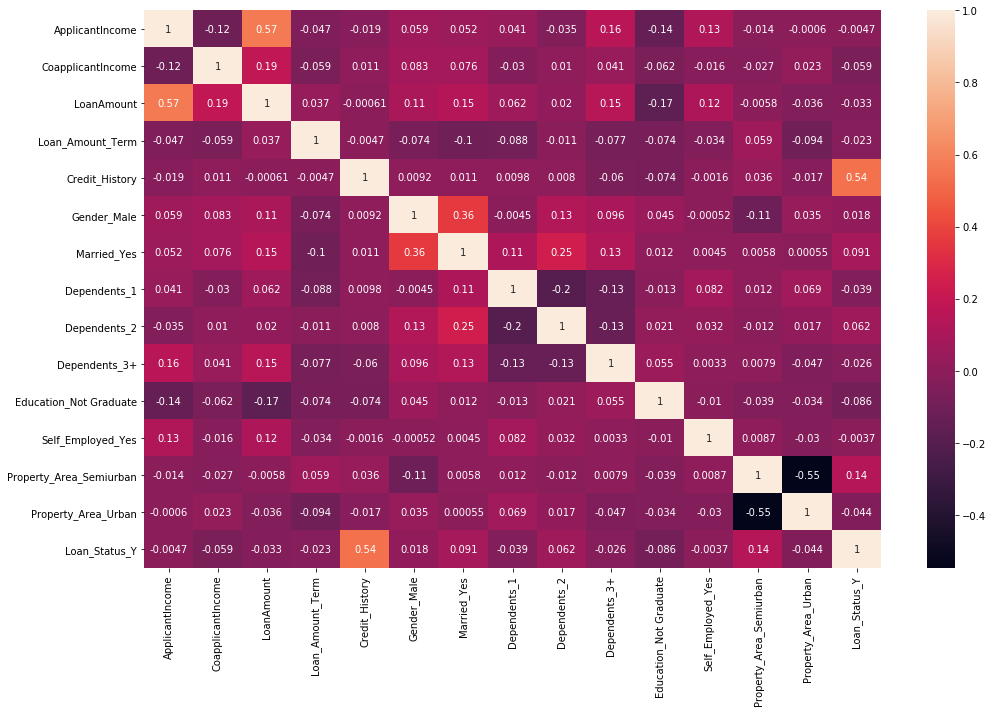

In [19]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(),annot=True)
plt.tight_layout()
plt.show()

In [20]:
#data preprocessing
X=df.drop('Loan_Status_Y',axis=1)
y=df['Loan_Status_Y']
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [21]:
print(X_train_scaled.shape,X_test_scaled.shape,y_train.shape,y_test.shape)

(491, 14) (123, 14) (491,) (123,)


In [22]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=1000)
model.fit(X_train_scaled,y_train)

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=None, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [23]:
y_predict=model.predict(X_test_scaled)

In [24]:
df_test=pd.DataFrame()
df_test['actual']=y_test.squeeze()
df_test['predict']=y_predict.squeeze()
df_test['diff']=y_predict.squeeze()-y_test.squeeze()

In [25]:
#model evaluation
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
acc=accuracy_score(y_predict,y_test)
clar=classification_report(y_predict,y_test)
cm=confusion_matrix(y_predict,y_test)
print(f"accuracy:{acc} \n classification:{clar} \n confusion:{cm}")

accuracy:0.7886178861788617 
 classification:              precision    recall  f1-score   support

           0       0.42      0.95      0.58        19
           1       0.99      0.76      0.86       104

    accuracy                           0.79       123
   macro avg       0.70      0.85      0.72       123
weighted avg       0.90      0.79      0.82       123
 
 confusion:[[18  1]
 [25 79]]


In [28]:
y_predict_train=model.predict(X_train_scaled)

In [29]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
acc_train=accuracy_score(y_train,y_predict_train)
clar_train=classification_report(y_train,y_predict_train)
cm_train=confusion_matrix(y_train,y_predict_train)
print(f"accuracy:{acc_train} \n classification:{clar_train} \n confusion:{cm_train}")

accuracy:0.8187372708757638 
 classification:              precision    recall  f1-score   support

           0       0.92      0.44      0.60       149
           1       0.80      0.98      0.88       342

    accuracy                           0.82       491
   macro avg       0.86      0.71      0.74       491
weighted avg       0.84      0.82      0.80       491
 
 confusion:[[ 66  83]
 [  6 336]]


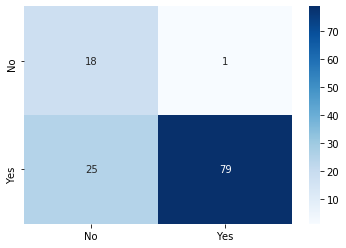

In [30]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.show()

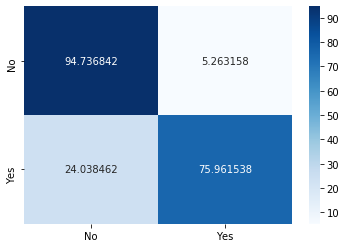

In [34]:
cm_percentage = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_percentage, annot=True, fmt='f', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])


In [35]:
#lets evaluate different models performance
from sklearn.tree import DecisionTreeClassifier

model_dtc = DecisionTreeClassifier()
model_dtc.fit(X_train_scaled,y_train)
prediction_dtc=model_dtc.predict(X_test_scaled)
cm2= confusion_matrix(y_test,prediction_dtc)

print(cm2)
print("##########")
print(accuracy_score(y_test,prediction_dtc))

[[23 20]
 [14 66]]
##########
0.7235772357723578


In [42]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
model_rfc=RandomForestClassifier()
model_abc=AdaBoostClassifier()
model_gbc=GradientBoostingClassifier()
model_rfc.fit(X_train_scaled,y_train)
model_abc.fit(X_train_scaled,y_train)
model_gbc.fit(X_train_scaled,y_train)
prediction_rfc=model_rfc.predict(X_test_scaled)
prediction_abc=model_abc.predict(X_test_scaled)
prediction_gbc=model_gbc.predict(X_test_scaled)
cm_rfc= confusion_matrix(y_test,prediction_rfc)
cm_abc= confusion_matrix(y_test,prediction_abc)
cm_gbc= confusion_matrix(y_test,prediction_gbc)
print(cm_rfc ,'\n', cm_abc ,'\n', cm_gbc)
print(accuracy_score(y_test,prediction_rfc),accuracy_score(y_test,prediction_abc),accuracy_score(y_test,prediction_gbc))

[[18 25]
 [ 3 77]] 
 [[19 24]
 [ 7 73]] 
 [[18 25]
 [ 2 78]]
0.7723577235772358 0.7479674796747967 0.7804878048780488
